In [8]:
#1. Импорты, seed, устройство
import random
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, EarlyStoppingCallback
)
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from tqdm.auto import tqdm

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [9]:
#2. Данные и первичный анализ
dataset = load_dataset("emotion")
print("Размеры splits:", {k: len(v) for k, v in dataset.items()})

label_names = dataset["train"].features["label"].names
print("Классы:", label_names)

print("\nПримеры:")
for i in range(5):
    ex = dataset["train"][i]
    print(f"{i}: {ex['text'][:80]}... -> {label_names[ex['label']]}")

Размеры splits: {'train': 16000, 'validation': 2000, 'test': 2000}
Классы: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

Примеры:
0: i didnt feel humiliated... -> sadness
1: i can go from feeling so hopeless to so damned hopeful just from being around so... -> sadness
2: im grabbing a minute to post i feel greedy wrong... -> anger
3: i am ever feeling nostalgic about the fireplace i will know that it is still on ... -> love
4: i am feeling grouchy... -> anger


In [10]:
#3. Демонстрация токенизации
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

sample_texts = [dataset["train"][i]["text"] for i in range(5)]
for text in sample_texts:
    tokens = tokenizer.tokenize(text)
    ids = tokenizer.encode(text, add_special_tokens=True)
    print(f"\nТекст: {text[:60]}...")
    print(f"Токены: {tokens[:10]}...")
    print(f"input_ids: {ids[:10]}...")
    mask = [1] * len(ids)
    print(f"attention_mask: {mask[:10]}...")
    print(f"[CLS]={tokenizer.cls_token}, [SEP]={tokenizer.sep_token}")

# padding и truncation
encoded = tokenizer(sample_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
print(f"\nПосле padding: форма input_ids = {encoded['input_ids'].shape}")

c:\Users\Matvey\repository_Stepanov\homeworks\HW13\venv\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



Текст: i didnt feel humiliated...
Токены: ['i', 'didn', '##t', 'feel', 'humiliated']...
input_ids: [101, 1045, 2134, 2102, 2514, 26608, 102]...
attention_mask: [1, 1, 1, 1, 1, 1, 1]...
[CLS]=[CLS], [SEP]=[SEP]

Текст: i can go from feeling so hopeless to so damned hopeful just ...
Токены: ['i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned']...
input_ids: [101, 1045, 2064, 2175, 2013, 3110, 2061, 20625, 2000, 2061]...
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]...
[CLS]=[CLS], [SEP]=[SEP]

Текст: im grabbing a minute to post i feel greedy wrong...
Токены: ['im', 'grabbing', 'a', 'minute', 'to', 'post', 'i', 'feel', 'greedy', 'wrong']...
input_ids: [101, 10047, 9775, 1037, 3371, 2000, 2695, 1045, 2514, 20505]...
attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]...
[CLS]=[CLS], [SEP]=[SEP]

Текст: i am ever feeling nostalgic about the fireplace i will know ...
Токены: ['i', 'am', 'ever', 'feeling', 'nos', '##tal', '##gic', 'about', 'the', 'fireplace']...
input_id

In [11]:
#4. Инференс готовой модели
pretrained_model_name = "bhadresh-savani/bert-base-uncased-emotion"
inference_tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name)
inference_model = AutoModelForSequenceClassification.from_pretrained(pretrained_model_name).to(device)

test_examples = [
    "I am so happy and excited!",
    "This is really disappointing and sad.",
    "I love you more than anything.",
    "That makes me furious!",
    "I'm afraid of the dark."
]

print("Инференс готовой модели:")
for text in test_examples:
    inputs = inference_tokenizer(text, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = inference_model(**inputs).logits
    pred_id = torch.argmax(logits, dim=1).item()
    pred_label = label_names[pred_id]
    print(f"\nТекст: {text}")
    print(f"Предсказание: {pred_label}")

print("\nМодель хорошо справляется с эмоциями, но для учебного fine-tuning мы дообучим BERT с нуля.")

Инференс готовой модели:

Текст: I am so happy and excited!
Предсказание: joy

Текст: This is really disappointing and sad.
Предсказание: sadness

Текст: I love you more than anything.
Предсказание: love

Текст: That makes me furious!
Предсказание: anger

Текст: I'm afraid of the dark.
Предсказание: fear

Модель хорошо справляется с эмоциями, но для учебного fine-tuning мы дообучим BERT с нуля.


In [12]:
#5. Fine-tuning для классификации
model_ft_name = "bert-base-uncased"
ft_tokenizer = AutoTokenizer.from_pretrained(model_ft_name)
dataset["train"] = dataset["train"].select(range(2000))

def tokenize_function(examples):
    return ft_tokenizer(examples["text"], padding="max_length", truncation=True, max_length=32)

tokenized_dataset = dataset.map(tokenize_function, batched=True)
tokenized_dataset = tokenized_dataset.remove_columns(["text"]).rename_column("label", "labels")
tokenized_dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

num_labels = len(label_names)
ft_model = AutoModelForSequenceClassification.from_pretrained(model_ft_name, num_labels=num_labels).to(device)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="macro")
    return {"accuracy": acc, "f1_macro": f1}

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_dir="./logs",
    logging_steps=50,
    seed=42,
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()

test_metrics = trainer.evaluate(tokenized_dataset["test"])
print("\nРезультаты на test:")
print(f"Accuracy: {test_metrics['eval_accuracy']:.4f}")
print(f"F1 macro: {test_metrics['eval_f1_macro']:.4f}")

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
 40%|████      | 50/125 [02:24<03:56,  3.15s/it]

{'loss': 1.513, 'learning_rate': 3e-05, 'epoch': 0.4}


 80%|████████  | 100/125 [04:57<01:10,  2.84s/it]

{'loss': 1.253, 'learning_rate': 1e-05, 'epoch': 0.8}


100%|██████████| 125/125 [07:29<00:00,  2.68s/it]Checkpoint destination directory ./results\checkpoint-125 already exists and is non-empty.Saving will proceed but saved results may be invalid.


{'eval_loss': 1.066508173942566, 'eval_accuracy': 0.602, 'eval_f1_macro': 0.29460134721850295, 'eval_runtime': 81.2881, 'eval_samples_per_second': 24.604, 'eval_steps_per_second': 0.394, 'epoch': 1.0}


100%|██████████| 125/125 [07:30<00:00,  3.60s/it]


{'train_runtime': 450.3841, 'train_samples_per_second': 4.441, 'train_steps_per_second': 0.278, 'train_loss': 1.3286692810058593, 'epoch': 1.0}


100%|██████████| 32/32 [01:19<00:00,  2.50s/it]


Результаты на test:
Accuracy: 0.6095
F1 macro: 0.2943


100%|██████████| 32/32 [01:19<00:00,  2.50s/it]


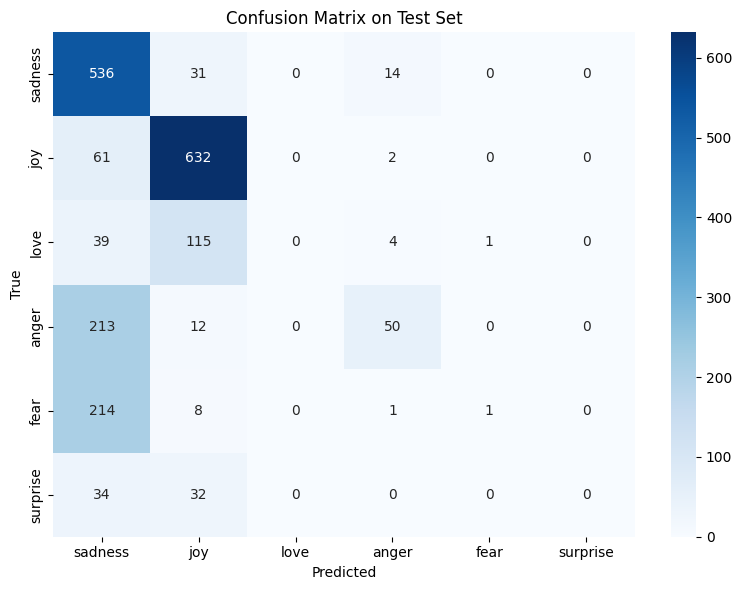

Сохранено sample_predictions.csv и confusion_matrix.png

Всего ошибок на test: 781 из 2000 (39.1%)

Примеры ошибок:
Текст: i cant walk into a shop anywhere where i do not feel uncomfortable...
Истинный: fear, Предсказанный: sadness

Текст: i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted des...
Истинный: joy, Предсказанный: sadness

Текст: i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week...
Истинный: anger, Предсказанный: sadness

Текст: i don t feel particularly agitated...
Истинный: fear, Предсказанный: sadness

Текст: i feel beautifully emotional knowing that these women of whom i knew just a handful were holding me ...
Истинный: sadness, Предсказанный: joy

Текст: i pay attention it deepens into a feeling of being invaded and helpless...
Истинный: fear, Предсказанный: sadness

Текст: i find myself in the odd position of feeling supportive of...
Истинный: love, Предсказанный: joy

Тек

In [13]:
#6. Оценка качества, матрица ошибок, предсказания
import os

# Создаём папку artifacts, если её нет
os.makedirs("artifacts", exist_ok=True)

predictions = trainer.predict(tokenized_dataset["test"])
pred_labels = np.argmax(predictions.predictions, axis=-1)
true_labels = predictions.label_ids

# Матрица ошибок
cm = confusion_matrix(true_labels, pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix on Test Set')
plt.tight_layout()
plt.savefig('artifacts/confusion_matrix.png')   # <-- путь без homeworks/HW13
plt.show()

# Сохраняем sample_predictions.csv
test_texts = dataset["test"]["text"]
softmax = torch.nn.Softmax(dim=1)
probs = softmax(torch.tensor(predictions.predictions)).numpy()
confidences = np.max(probs, axis=1)

sample_df = pd.DataFrame({
    'text': test_texts[:100],
    'true_label': [label_names[l] for l in true_labels[:100]],
    'pred_label': [label_names[p] for p in pred_labels[:100]],
    'confidence': confidences[:100]
})
sample_df.to_csv('artifacts/sample_predictions.csv', index=False)
print("Сохранено sample_predictions.csv и confusion_matrix.png")

# Анализ ошибок
errors = np.where(pred_labels != true_labels)[0]
print(f"\nВсего ошибок на test: {len(errors)} из {len(true_labels)} ({len(errors)/len(true_labels)*100:.1f}%)")
print("\nПримеры ошибок:")
for idx in errors[:10]:
    print(f"Текст: {test_texts[idx][:100]}...")
    print(f"Истинный: {label_names[true_labels[idx]]}, Предсказанный: {label_names[pred_labels[idx]]}\n")